In [2]:
import numpy as np 
from scipy.stats import norm, linregress
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


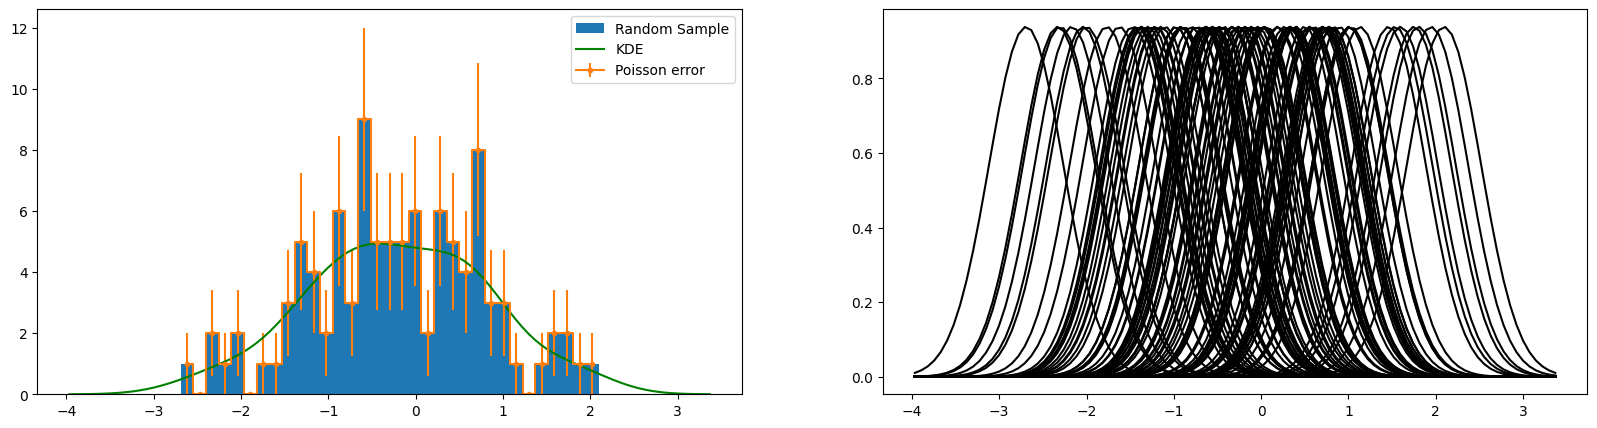

In [3]:

N=100
mu1=0
std1=1.0
def kde_gaussian(mu1, std1, N):
    
    x=norm.rvs(mu1,std1,size=N)

    # bandwidth
    h = 1.06 * x.std() * x.size**(-1/5)

    # evaluation grid
    t = np.linspace(x.min()-3*h, x.max()+3*h, N)

    # gaussian functions (NOT random samples)
    gaussians = np.array([norm.pdf(t, loc=xi, scale=h) for xi in x])

    # KDE sum
    g = np.sum(gaussians, axis=0)
    plt.hist
    # histogram
    fig , (ax1,ax2) = plt.subplots(1,2,figsize=(20,5))
    y,bins,_ = ax1.hist(x, bins=int(N*(1/3)), label="Random Sample")
    bin_centers = 0.5*(bins[1:] + bins[:-1])
    ax1.errorbar(
        bin_centers,
        y,
        yerr = (y)**0.5,
        marker = '.',
        drawstyle = 'steps-mid',
        label="Poisson error"
    )
    # normalize KDE
    hist_int = np.trapezoid(y, bins[:-1])
    g_int = np.trapezoid(g, t)
    g_norm = g * (hist_int / g_int)
    ax1.plot(t, g_norm, c='g', label="KDE")
    # plot individual kernels
    for g_i in gaussians:
        ax2.plot(t, g_i, c='k')

    ax1.legend()
    plt.show()
kde_gaussian(mu1, std1, N)


2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

--2026-06-13 18:30:40--  https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6025:18::a27d:4512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/70o67xqfkicx6o3pofl37/two_categories_scatter_plot.png?rlkey=b1wnq5kkwhthz0cevmq0mxf35 [following]
--2026-06-13 18:30:41--  https://www.dropbox.com/scl/fi/70o67xqfkicx6o3pofl37/two_categories_scatter_plot.png?rlkey=b1wnq5kkwhthz0cevmq0mxf35
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc1e09a9e73eb84d6c1fe8b8cf36.dl.dropboxusercontent.com/cd/0/inline/DCUzrRgXI4vQ4_FYk0zmuaagZRXCiz9COjIpSixqkc0NxQha05uOGes86iJFsvFAuc47PSXMz2ryLylq1Z3VLwohK-8DmlJl2f6XKUF5_RKTBAXLf_cgJo6oJ_UGdhiagWU/file# [following]
--2026-06-13 18:30:41--  https://uc1e09a9e73eb84d6c1fe8b8cf36.

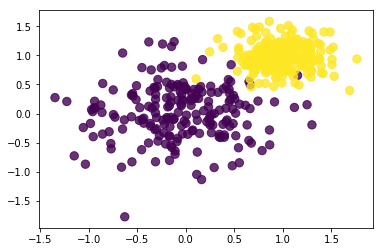

In [4]:
! wget https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
from IPython.display import Image
Image('two_categories_scatter_plot.png')

{'Category_1': [array([[ 0.09230914,  1.0985076 ,  0.44690528, -0.70070305, -0.34952683,
         1.3058521 , -1.198217  , -0.32243915,  0.87128401, -1.64180833,
        -0.78967801,  2.0639379 , -0.03737712, -0.19961215,  0.99578922,
        -0.10311235, -0.15648108,  0.44943543, -0.96697529,  0.08763543,
         0.78486963,  0.59655092,  0.22708519, -1.41566302, -0.33851171,
        -0.14855398,  1.81725738,  1.15072377, -1.05126893, -0.78767909,
         1.83950778, -0.55643187, -0.95341144,  0.28945816, -0.18829453,
        -0.93659168,  0.25999038, -0.45826013,  0.31622187,  0.81574298,
        -1.19573023,  1.38802112, -0.41703062,  1.71209412, -1.20532747,
        -0.74926062, -0.81344283, -2.06457206,  0.53645474, -1.49162386,
        -0.05049839,  0.5777252 ,  0.07296664,  0.77764618,  0.77767785,
        -0.53017692, -0.48968391,  1.45939025,  0.71179739, -2.27764883,
        -0.9829185 , -0.23369898, -0.90145404, -1.88840274,  0.13078823,
        -0.23538126, -0.27361691, -

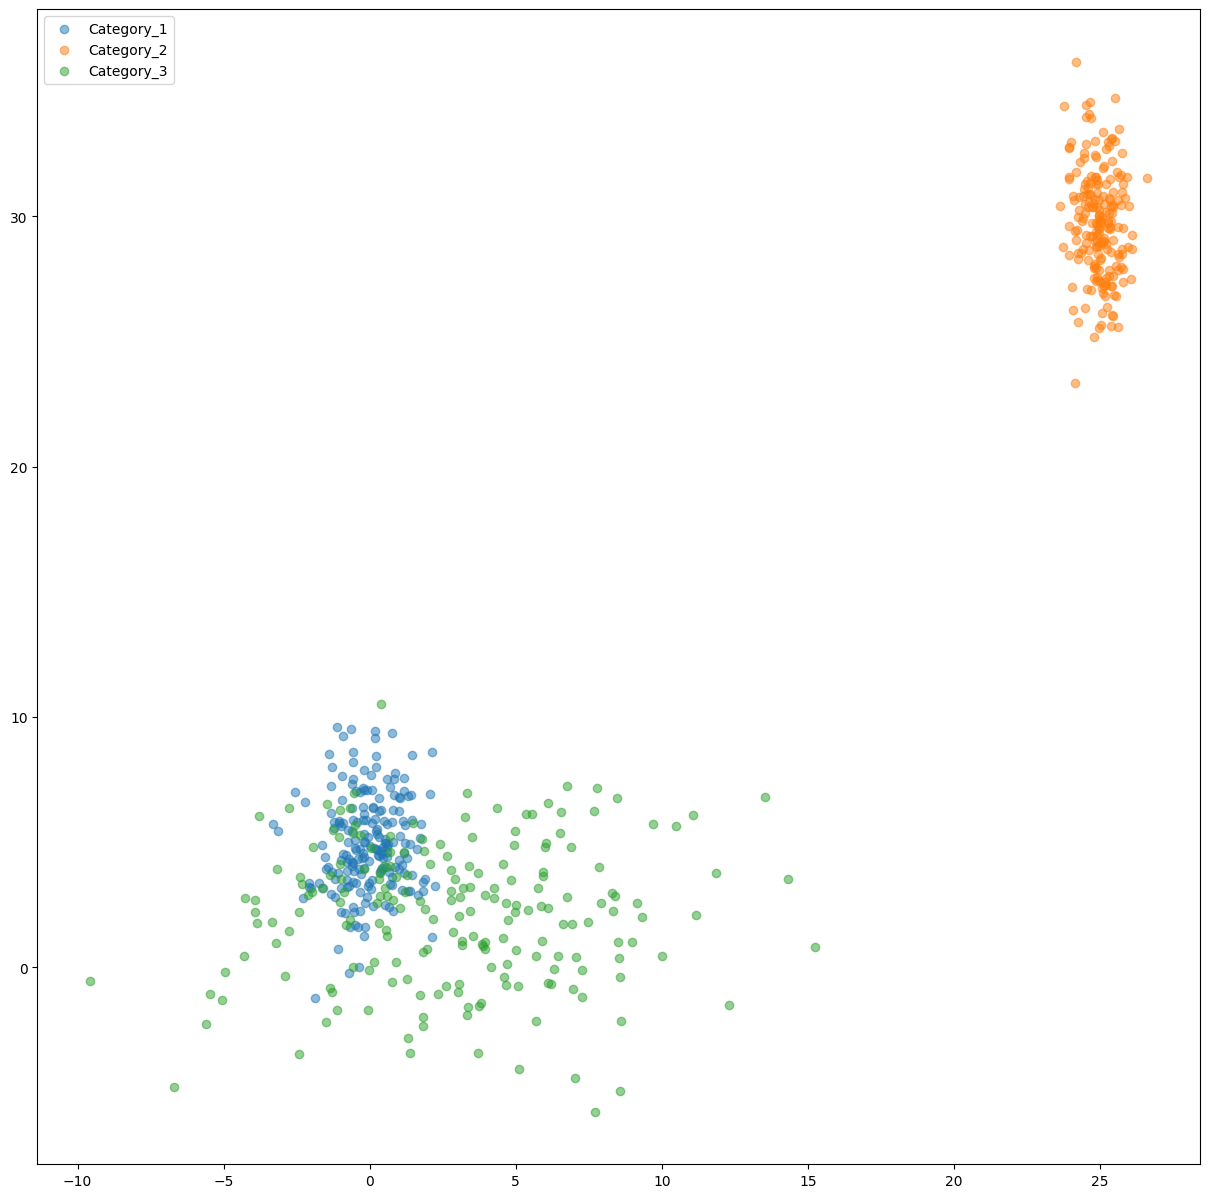

In [5]:
def ndplot(mu1,mu2,std1,std2,N):
    dic = {}
    for k, (mu1,mu2,std1, std2) in enumerate(zip(mu1,mu2,std1,std2)):
        x = np.random.normal(mu1,std1,size=(2,N))
        y = np.random.normal(mu2,std2,size=(2,N))
        dic[f"Category_{k+1}"]= [x,y]
    print(dic)
    df = pd.DataFrame(dic)
    fig, axes = plt.subplots(1,1,figsize=(15,15))
    for m ,i in enumerate(df.columns):
        
        axes.scatter(x=df[i][0], y=df[i][1], label=i, alpha=0.5)
        #axes.set_xlabel(i)
        #axes.set_ylabel(j)
        axes.legend()
    plt.show()

ndplot([0,25,3],[5,30,2],[1,0.5,4],[2,2,3],100)
        
        

3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

In [6]:
!wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy

--2026-06-13 18:30:43--  https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6025:18::a27d:4512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/cu0wjpyhyoy57w9yupavt/residuals_261.npy?rlkey=9rx6zjagfspm9mfc1jc3zejbt [following]
--2026-06-13 18:30:43--  https://www.dropbox.com/scl/fi/cu0wjpyhyoy57w9yupavt/residuals_261.npy?rlkey=9rx6zjagfspm9mfc1jc3zejbt
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucda9300f0b065e436d425a5897c.dl.dropboxusercontent.com/cd/0/inline/DCXvfRQLeSkGWKrJRNQU3XCqPyY-t_mZ2edS6pnJFfAM-3U43zDmBdeF9mGGyYJoZ8jVD6FRZxTvyRreEVZWIaUOt5mtf0ezY03AA9yF56Ju8gCSeBOFaX5Y2Mgvzetxyac/file# [following]
--2026-06-13 18:30:44--  https://ucda9300f0b065e436d425a5897c.dl.dropboxusercontent.com/cd/0/inline/DCXv

In [7]:
M = np.load('residuals_261.npy',allow_pickle=True)

In [11]:
df = pd.DataFrame.from_dict(M.item())
clean = df[np.abs(df['residuals']) < 2]
res = linregress(clean['distances'],clean['residuals'])
x = np.linspace(clean['distances'].min(), clean['distances'].max())


<positron-console-cell-10>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


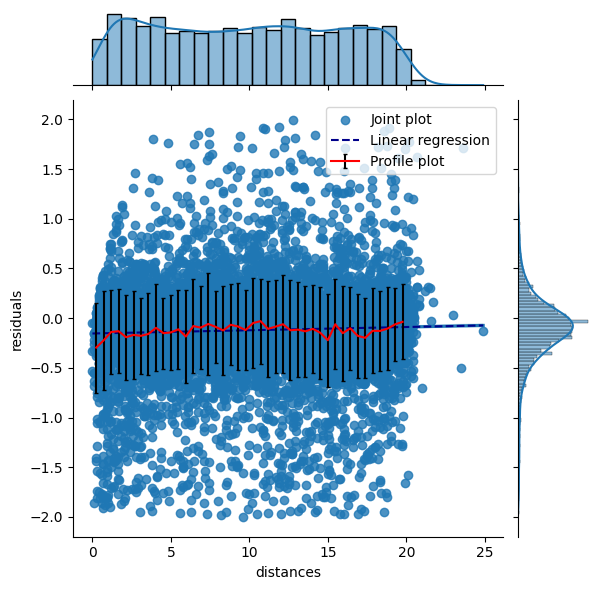

In [10]:
sns.jointplot(x = "distances", y = "residuals", data = clean, label = 'Joint plot', kind='reg')

#Plot of the linear regression line
x_axis = np.linspace(clean['distances'].min(), clean['distances'].max())
plt.plot(x_axis, (res.slope * x_axis) + res.intercept, linestyle = '--', color = 'darkblue', label = 'Linear regression')

#Bin numbers with Rice rule
bin_edges = np.linspace(0, 20, int(2 * (clean.shape[0] ** (1/3))))

#There are some distances that are greater than 20.0, so i discard them in the bin count
clean = clean[clean['distances'] < 20.0]

#np.digitize assigns the index of the bin to which each value belongs
bins_x = np.digitize(clean["distances"], bin_edges)

#Evaluating bins' midpoints
x = (bin_edges[1:] + bin_edges[:-1]) / 2

#Adding the bin-index array evaluated with np.digitize as a new column to the cleanframe
clean.loc[:, 'bin'] = bins_x

#Evaluating mean and standard deviation with respect to residuals clean
y = clean.groupby('bin').mean()['residuals']
erry = clean.groupby('bin').std()['residuals']

#Plotting errorbars
plt.errorbar(x, y, yerr = erry, color = 'r', ecolor = 'black', label = 'Profile plot', capsize = 1.5)

plt.legend()
plt.show()

1    20
2    30
3    40
dtype: int64
